# Reranking Goldilocks: A Fresh, Comprehensive Search

Follow-up to `08_reranking_optimization.ipynb`, and a sibling to `11_chunking_goldilocks.ipynb`
/ `12_retriever_goldilocks.ipynb` / `13_query_transformation_goldilocks.ipynb`. Applies the
same fix to the reranking question that the prior three notebooks applied to their own
modules:

1. **`08` scored on 5 unlucky, non-fixed samples per reranker**, with judge failures
   silently dropped -- the same noise problem the earlier audits flagged.
2. **`08` froze chunking at 192t semantic chunks and the retriever at Dense MMR (k=8)** --
   neither is this repo's actual best-known config anymore (`11`, `12`, `13` superseded
   both, plus established HyDE doc+query as the best retrieval-side query transformation).
3. **`08` reranked the exact same k=8 candidate set the generator would have used anyway.**
   Reranking is only interesting when it has a wider candidate pool to work with than the
   final context -- rerank a k=8 pool down to k=8 and a reranker can only reorder, never
   improve recall. `08` never varied the *candidate pool width* independently of the
   *final kept count*, so its finding ("reranking hurts") was never tested under the
   condition where reranking is supposed to help.
4. **`08`'s own write-up (`RERANKING_ANALYSIS.md`) attributed the failure to "Dense MMR's
   diversity being destroyed by reranking's pure-relevance scoring."** That diagnosis is
   itself conditional on Dense MMR being the retriever -- `12` replaced Dense MMR with
   hybrid search (BM25+dense) as the winning retriever, which has no diversity mechanism to
   destroy in the first place. The MMR-specific failure mode `08` diagnosed may not apply to
   this repo's actual retrieval stack anymore.

This notebook fixes what's fixable in a single sitting: (1) via the fixed 20-question
evaluation set with retried judge annotations and the same composite score `11`/`12`/`13`
used; (2) by building on top of `11`, `12`, and `13`'s actual winning configs (sentence +
metadata chunks @ 64t, hybrid retrieval @ alpha=0.3, HyDE doc+query driving retrieval only);
(3) by running a proper three-phase search (reranker model -> candidate pool width -> final
kept count) that actually gives reranking a wider pool to work with, instead of a pool equal
to the final context size.


## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk matplotlib rank-bm25 requests


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Imports & Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser

load_dotenv()
openrouter_token = os.environ.get("OPENROUTER_TOKEN")

import sys


def _add_ragbench_lib_to_path():
    for candidate in (os.getcwd(), os.path.join(os.getcwd(), "delucion_dataset")):
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.chunking import count_tokens, get_sentences
from ragbench_lib.retrievers import HybridRetriever
from ragbench_lib.trace_eval import (
    annotate_response_for_metrics_with_retry,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)

print("✓ All imports successful")


/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset (fixed evaluation set)

Same fixed-sample mechanism as `11`/`12`/`13` -- `EVAL_SAMPLE_SIZE` questions chosen once,
up front, and reused for every config in every phase below.

In [3]:
DATASET_NAME = "delucionqa"
EVAL_SAMPLE_SIZE = 20

print("Loading dataset...")
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=max(EVAL_SAMPLE_SIZE + 10, 30))
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")

eval_questions_df = docs_df.drop_duplicates(subset=["row_id"]).head(EVAL_SAMPLE_SIZE).reset_index(drop=True)
print(f"✓ Fixed evaluation set: {len(eval_questions_df)} unique questions (reused for every config below)")


Loading dataset...
✓ Loaded 90 documents from 30 unique questions
✓ Fixed evaluation set: 20 unique questions (reused for every config below)


## Step 4: Models

In [4]:
embedding_model = get_embedding_model(openrouter_token)
llm = get_generation_llm(openrouter_token)
query_llm = get_generation_llm(openrouter_token, temperature=0.7, max_tokens=256)
llama_judge = get_judge_llm(openrouter_token)
prompt = RAG_GENERATION_PROMPT

print("✓ Embedding model, generator, query-transform LLM, and judge configured")


✓ Embedding model, generator, query-transform LLM, and judge configured


## Step 5: Fixed Chunking + Retrieval + Query-Transformation Foundation

Every layer below `13`'s winning line is frozen at its own winning config:

- **Chunking**: sentence-level + metadata heading, 64-token target, 10% overlap (`11`)
- **Retriever**: hybrid (BM25 + dense), alpha=0.3 (`12`) -- built once at a wide k so every
  phase below can slice smaller candidate pools out of the same ranked list without
  rebuilding the vector store or re-embedding anything
- **Query transformation**: HyDE, one hypothetical document concatenated with the original
  query, driving retrieval only -- the generator (and the reranker, see Step 6) always see
  the original question (`13`)

Reranking is the only independent variable in this notebook.

In [5]:
CHUNK_TARGET_TOKENS = 64
CHUNK_OVERLAP_FRACTION = 0.10
RETRIEVER_ALPHA = 0.3
MAX_CANDIDATE_K = 40  # widest candidate pool any phase below will request


def sentence_level_chunks(docs_df, target_tokens=64, overlap_fraction=0.1):
    documents = []
    for _, doc in docs_df.iterrows():
        sentences = get_sentences(doc["text"])
        if not sentences:
            continue
        sent_tokens = [count_tokens(s) for s in sentences]
        n = len(sentences)
        i, chunk_idx = 0, 0
        while i < n:
            chunk_sents, chunk_tok_count, j = [], 0, i
            while j < n and (not chunk_sents or chunk_tok_count + sent_tokens[j] <= target_tokens):
                chunk_sents.append(sentences[j])
                chunk_tok_count += sent_tokens[j]
                j += 1
            chunk_text = " ".join(chunk_sents)
            documents.append(Document(
                page_content=chunk_text,
                metadata={
                    "chunk_id": f"{doc['doc_id']}_sent{chunk_idx}",
                    "row_id": doc["row_id"],
                    "tokens": count_tokens(chunk_text),
                },
            ))
            chunk_idx += 1
            overlap_count = int(len(chunk_sents) * overlap_fraction)
            step = max(len(chunk_sents) - overlap_count, 1)
            i += step
    return documents


def metadata_enhanced_chunks(docs_df, target_tokens=64, overlap_fraction=0.1):
    documents = sentence_level_chunks(docs_df, target_tokens=target_tokens, overlap_fraction=overlap_fraction)

    doc_id_to_heading = {}
    for _, doc in docs_df.iterrows():
        sentences = get_sentences(doc["text"])
        heading = sentences[0] if sentences else doc["text"][:80]
        doc_id_to_heading[doc["doc_id"]] = " ".join(heading.split()[:12])

    enhanced = []
    for d in documents:
        source_doc_id = d.metadata["chunk_id"].rsplit("_sent", 1)[0]
        heading = doc_id_to_heading.get(source_doc_id, "")
        new_text = f"[Context: {heading}]\n{d.page_content}"
        enhanced.append(Document(
            page_content=new_text,
            metadata={**d.metadata, "tokens": count_tokens(new_text)},
        ))
    return enhanced


def apply_hyde(query, llm, n_docs=1, concat_with_query=True):
    """Winning HyDE config from 13: 1 hypothetical doc, concatenated with the query,
    used to drive retrieval only."""
    pseudo_docs = []
    for _ in range(n_docs):
        p = f"""Write a comprehensive document that would answer this question:

'{query}'

The document should be detailed and informative, covering all aspects of the answer."""
        try:
            pseudo_docs.append(llm.invoke(p).content.strip())
        except Exception:
            pass
    if not pseudo_docs:
        return query
    combined = " ".join(pseudo_docs)
    return f"{query} {combined}" if concat_with_query else combined


print("Building fixed chunking foundation (sentence + metadata, 64t, 10% overlap)...")
documents = metadata_enhanced_chunks(docs_df, target_tokens=CHUNK_TARGET_TOKENS, overlap_fraction=CHUNK_OVERLAP_FRACTION)
print(f"✓ Built {len(documents)} chunks, avg {np.mean([d.metadata['tokens'] for d in documents]):.0f} tokens/chunk")

print(f"Building wide hybrid retriever foundation (alpha=0.3, k={MAX_CANDIDATE_K})...")
wide_retriever = HybridRetriever(documents, embedding_model, k=MAX_CANDIDATE_K, alpha=RETRIEVER_ALPHA,
                                  dataset_name=DATASET_NAME, config_name="rerank_foundation")
print("✓ Wide hybrid retriever ready -- every phase below slices its candidate pool out of this ranked list")


def get_candidates(retrieval_query, candidate_k):
    """Top candidate_k docs from the wide hybrid retriever's ranked list. Slicing a
    prefix of the top-MAX_CANDIDATE_K ranking is equivalent to querying with
    k=candidate_k directly (both are the same descending sort by combined score), so
    this reuses one embedding pass across every candidate_k tested below."""
    return wide_retriever.retrieve(retrieval_query)[:candidate_k]


Building fixed chunking foundation (sentence + metadata, 64t, 10% overlap)...
✓ Built 456 chunks, avg 68 tokens/chunk
Building wide hybrid retriever foundation (alpha=0.3, k=40)...
✓ Wide hybrid retriever ready -- every phase below slices its candidate pool out of this ranked list


## Step 6: Reranker Implementations

`NoReranker` is the control: it keeps the hybrid+HyDE ranking as-is and just truncates to
`top_k`. The three OpenRouter cross-encoder rerankers (`08`'s own selection, reused
verbatim) rescore the candidate pool against the **original** question -- not the HyDE
retrieval string -- since reranking's job is to judge relevance to what the user actually
asked, and the pseudo-document was only ever meant to widen retrieval's net.

In [6]:
class NoReranker:
    """Control: keep the hybrid+HyDE candidate ranking, just truncate."""
    def rerank(self, query, documents, top_k):
        return documents[:top_k]


class OpenRouterReranker:
    """Cross-encoder reranking via OpenRouter's dedicated /api/v1/rerank endpoint."""

    def __init__(self, model_name, api_key):
        self.model_name = model_name
        self.api_key = api_key
        self.endpoint = "https://openrouter.ai/api/v1/rerank"

    def rerank(self, query, documents, top_k):
        if not documents:
            return documents
        doc_texts = [d.page_content for d in documents]
        headers = {"Authorization": f"Bearer {self.api_key}", "Content-Type": "application/json"}
        payload = {"model": self.model_name, "query": query, "documents": doc_texts, "top_n": top_k}
        try:
            response = requests.post(self.endpoint, headers=headers, json=payload, timeout=30)
            response.raise_for_status()
            result = response.json()
            if "results" in result:
                ranked = sorted(result["results"], key=lambda r: r.get("relevance_score", 0), reverse=True)
                indices = [r["index"] for r in ranked[:top_k]]
                return [documents[i] for i in indices]
            return documents[:top_k]
        except Exception as e:
            print(f"    [DEBUG] rerank error ({self.model_name}): {str(e)[:60]}")
            return documents[:top_k]


RERANKER_BUILDERS = {
    "no_rerank": lambda: NoReranker(),
    "cohere_v35": lambda: OpenRouterReranker("cohere/rerank-v3.5", openrouter_token),
    "cohere_4pro": lambda: OpenRouterReranker("cohere/rerank-4-pro", openrouter_token),
    "nvidia_nemotron": lambda: OpenRouterReranker("nvidia/llama-nemotron-rerank-vl-1b-v2:free", openrouter_token),
}

print("✓ Reranker implementations ready (no_rerank, cohere_v35, cohere_4pro, nvidia_nemotron)")


✓ Reranker implementations ready (no_rerank, cohere_v35, cohere_4pro, nvidia_nemotron)


## Step 7: Evaluation Runner

Every config runs the fixed 20-question set through: HyDE-transform the query -> retrieve
`candidate_k` hybrid-ranked candidates -> rerank against the **original** question, keeping
`final_k` -> generate from the original question (per `13`'s finding that the generator
should never see the transformed string) -> retry judge annotation up to 3x -> compute
TRACe metrics + the same composite score `11`/`12`/`13` used.

In [7]:
def evaluate_reranking_config(config_name, reranker, candidate_k, final_k, eval_questions_df, max_annotate_attempts=3):
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = prompt | llm | StrOutputParser()

    per_sample = []
    n_failed = 0
    for _, row in eval_questions_df.iterrows():
        original_question = row["question"]
        try:
            retrieval_query = apply_hyde(original_question, query_llm, n_docs=1, concat_with_query=True)
            candidates = get_candidates(retrieval_query, candidate_k)
            reranked_docs = reranker.rerank(original_question, candidates, top_k=final_k)
            retrieved_texts = [d.page_content for d in reranked_docs]

            response_text = rag_chain.invoke({"context": format_docs(reranked_docs), "question": original_question})

            annotation = annotate_response_for_metrics_with_retry(
                llama_judge, retrieved_texts, original_question, response_text, max_attempts=max_annotate_attempts
            )
            if annotation["success"]:
                per_sample.append({
                    "context_relevance": compute_context_relevance(retrieved_texts, annotation),
                    "utilization": compute_utilization(retrieved_texts, annotation),
                    "completeness": compute_completeness(annotation),
                    "adherence": compute_adherence(annotation),
                })
            else:
                n_failed += 1
        except Exception:
            n_failed += 1

    result = {
        "config": config_name,
        "candidate_k": candidate_k,
        "final_k": final_k,
        "n_eval": len(per_sample),
        "n_failed": n_failed,
        "context_relevance": np.mean([r["context_relevance"] for r in per_sample]) if per_sample else None,
        "utilization": np.mean([r["utilization"] for r in per_sample]) if per_sample else None,
        "completeness": np.mean([r["completeness"] for r in per_sample]) if per_sample else None,
        "adherence": np.mean([r["adherence"] for r in per_sample]) if per_sample else None,
    }
    if per_sample:
        result["composite"] = (
            0.35 * result["context_relevance"]
            + 0.15 * result["utilization"]
            + 0.15 * result["completeness"]
            + 0.35 * result["adherence"]
        )
    else:
        result["composite"] = None
    return result


print("✓ evaluate_reranking_config defined")


✓ evaluate_reranking_config defined


## Step 8: Phase 1 -- Reranker Model Comparison

Every reranker gets a candidate pool of 20 (wider than the final k=4 context, unlike `08`'s
rerank-8-down-to-8 setup) and keeps the top 4 -- matching `12`'s winning final context size.
Isolates **reranker choice**, with candidate pool width fixed.

In [8]:
CANDIDATE_K_PHASE1 = 20
FINAL_K_PHASE1 = 4

print("=" * 100)
print(f"PHASE 1: RERANKER MODEL COMPARISON (candidate_k={CANDIDATE_K_PHASE1}, final_k={FINAL_K_PHASE1}), {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase1_results = []
for name, builder in RERANKER_BUILDERS.items():
    print(f"\n--- {name} ---")
    reranker = builder()
    result = evaluate_reranking_config(f"p1_{name}", reranker, CANDIDATE_K_PHASE1, FINAL_K_PHASE1, eval_questions_df)
    phase1_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
              f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase1_df = pd.DataFrame(phase1_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 1 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase1_df)


PHASE 1: RERANKER MODEL COMPARISON (candidate_k=20, final_k=4), 20 fixed questions

--- no_rerank ---
  CR=0.4251 Util=0.2236 Comp=0.5846 Adh=1.0000 Composite=0.6200  (failed 0/20)

--- cohere_v35 ---
  CR=0.4198 Util=0.2395 Comp=0.5900 Adh=0.9500 Composite=0.6039  (failed 0/20)

--- cohere_4pro ---
  CR=0.4886 Util=0.2362 Comp=0.5585 Adh=0.9500 Composite=0.6227  (failed 0/20)

--- nvidia_nemotron ---
  CR=0.4562 Util=0.2127 Comp=0.4936 Adh=0.9500 Composite=0.5981  (failed 0/20)

PHASE 1 RESULTS (ranked by composite score)


,config,candidate_k,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
2,p1_cohere_4pro,20,4,20,0,0.488630,0.236220,0.558495,0.95,0.622728
0,p1_no_rerank,20,4,20,0,0.425075,0.223585,0.584640,1.00,0.620010
1,p1_cohere_v35,20,4,20,0,0.419795,0.239525,0.590000,0.95,0.603857
3,p1_nvidia_nemotron,20,4,20,0,0.456195,0.212665,0.493560,0.95,0.598102


## Step 9: Phase 2 -- Candidate Pool Width Sweep

Takes Phase 1's winning reranker (falling back to the best *actual* reranker if
`no_rerank` wins, since `no_rerank` has nothing to sweep) and varies how wide a candidate
pool it gets to rerank down from, holding `final_k=4` fixed -- isolates **how much
pre-rerank recall matters**, the exact axis `08` never varied.

In [9]:
phase1_winner = phase1_df.iloc[0]["config"].replace("p1_", "")
if phase1_winner == "no_rerank":
    real_rerankers = phase1_df[~phase1_df["config"].str.contains("no_rerank")].dropna(subset=["composite"])
    phase2_method = real_rerankers.iloc[0]["config"].replace("p1_", "") if not real_rerankers.empty else "cohere_v35"
    print(f"Phase 1 winner is 'no_rerank' (nothing to sweep); using best actual reranker "
          f"'{phase2_method}' for Phase 2/3 instead.\n")
else:
    phase2_method = phase1_winner
    print(f"Phase 1 winner: {phase2_method} -- sweeping candidate pool width next\n")

candidate_k_values = [4, 8, 12, 20, 30]
FINAL_K_PHASE2 = 4

print("=" * 100)
print(f"PHASE 2: CANDIDATE POOL WIDTH SWEEP for '{phase2_method}' (final_k={FINAL_K_PHASE2}), {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase2_results = []
for candidate_k in candidate_k_values:
    print(f"\n--- {phase2_method} @ candidate_k={candidate_k}, final_k={FINAL_K_PHASE2} ---")
    reranker = RERANKER_BUILDERS[phase2_method]()
    result = evaluate_reranking_config(f"p2_{phase2_method}_ck{candidate_k}", reranker, candidate_k, FINAL_K_PHASE2, eval_questions_df)
    phase2_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase2_df = pd.DataFrame(phase2_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 2 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase2_df)


Phase 1 winner: cohere_4pro -- sweeping candidate pool width next

PHASE 2: CANDIDATE POOL WIDTH SWEEP for 'cohere_4pro' (final_k=4), 20 fixed questions

--- cohere_4pro @ candidate_k=4, final_k=4 ---
  CR=0.3718 Adh=0.9500 Composite=0.5798  (failed 0/20)

--- cohere_4pro @ candidate_k=8, final_k=4 ---
  CR=0.4419 Adh=0.8500 Composite=0.5773  (failed 0/20)

--- cohere_4pro @ candidate_k=12, final_k=4 ---
  CR=0.4706 Adh=0.8000 Composite=0.5626  (failed 0/20)

--- cohere_4pro @ candidate_k=20, final_k=4 ---
  CR=0.4772 Adh=0.9000 Composite=0.6158  (failed 0/20)

--- cohere_4pro @ candidate_k=30, final_k=4 ---
  CR=0.4512 Adh=0.9000 Composite=0.5835  (failed 0/20)

PHASE 2 RESULTS (ranked by composite score)


,config,candidate_k,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
3,p2_cohere_4pro_ck20,20,4,20,0,0.477180,0.294235,0.597990,0.90,0.615847
4,p2_cohere_4pro_ck30,30,4,20,0,0.451160,0.212835,0.524655,0.90,0.583530
0,p2_cohere_4pro_ck4,4,4,20,0,0.371765,0.187875,0.593335,0.95,0.579799
1,p2_cohere_4pro_ck8,8,4,20,0,0.441875,0.225235,0.609210,0.85,0.577323
2,p2_cohere_4pro_ck12,12,4,20,0,0.470625,0.222240,0.563865,0.80,0.562634


## Step 10: Phase 3 -- Final Kept-Count Sweep

Takes Phase 2's winning candidate pool width and sweeps how many reranked documents
actually get kept for generation, holding reranker and candidate pool fixed -- isolates
**final context size post-rerank**, mirroring `12`'s own k sweep but downstream of
reranking instead of raw retrieval.

In [10]:
phase2_winner_config = phase2_df.iloc[0]["config"]
phase2_winner_candidate_k = int(phase2_df.iloc[0]["candidate_k"])
print(f"Phase 2 winner candidate_k: {phase2_winner_candidate_k} -- sweeping final_k next\n")

final_k_values = [c for c in [2, 4, 6, 8, 12] if c <= phase2_winner_candidate_k]

print("=" * 100)
print(f"PHASE 3: FINAL KEPT-COUNT SWEEP for '{phase2_method}' @ candidate_k={phase2_winner_candidate_k}, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase3_results = []
for final_k in final_k_values:
    print(f"\n--- {phase2_method} @ candidate_k={phase2_winner_candidate_k}, final_k={final_k} ---")
    reranker = RERANKER_BUILDERS[phase2_method]()
    result = evaluate_reranking_config(f"p3_{phase2_method}_ck{phase2_winner_candidate_k}_fk{final_k}", reranker,
                                        phase2_winner_candidate_k, final_k, eval_questions_df)
    phase3_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase3_df = pd.DataFrame(phase3_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 3 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase3_df)


Phase 2 winner candidate_k: 20 -- sweeping final_k next

PHASE 3: FINAL KEPT-COUNT SWEEP for 'cohere_4pro' @ candidate_k=20, 20 fixed questions

--- cohere_4pro @ candidate_k=20, final_k=2 ---
  CR=0.6190 Adh=0.9500 Composite=0.7093  (failed 0/20)

--- cohere_4pro @ candidate_k=20, final_k=4 ---
  CR=0.4917 Adh=0.8500 Composite=0.5835  (failed 0/20)

--- cohere_4pro @ candidate_k=20, final_k=6 ---
  CR=0.3406 Adh=1.0000 Composite=0.5802  (failed 1/20)

--- cohere_4pro @ candidate_k=20, final_k=8 ---
  CR=0.3052 Adh=0.8500 Composite=0.4944  (failed 0/20)

--- cohere_4pro @ candidate_k=20, final_k=12 ---
  CR=0.2178 Adh=0.9500 Composite=0.4958  (failed 0/20)

PHASE 3 RESULTS (ranked by composite score)


,config,candidate_k,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
0,p3_cohere_4pro_ck20_fk2,20,2,20,0,0.619030,0.392085,0.675835,0.95,0.709348
1,p3_cohere_4pro_ck20_fk4,20,4,20,0,0.491655,0.236320,0.522955,0.85,0.583471
2,p3_cohere_4pro_ck20_fk6,20,6,19,1,0.340563,0.170342,0.569416,1.00,0.580161
4,p3_cohere_4pro_ck20_fk12,20,12,20,0,0.217845,0.085410,0.495130,0.95,0.495827
3,p3_cohere_4pro_ck20_fk8,20,8,20,0,0.305230,0.114715,0.485945,0.85,0.494429


## Step 11: Visualize the Search

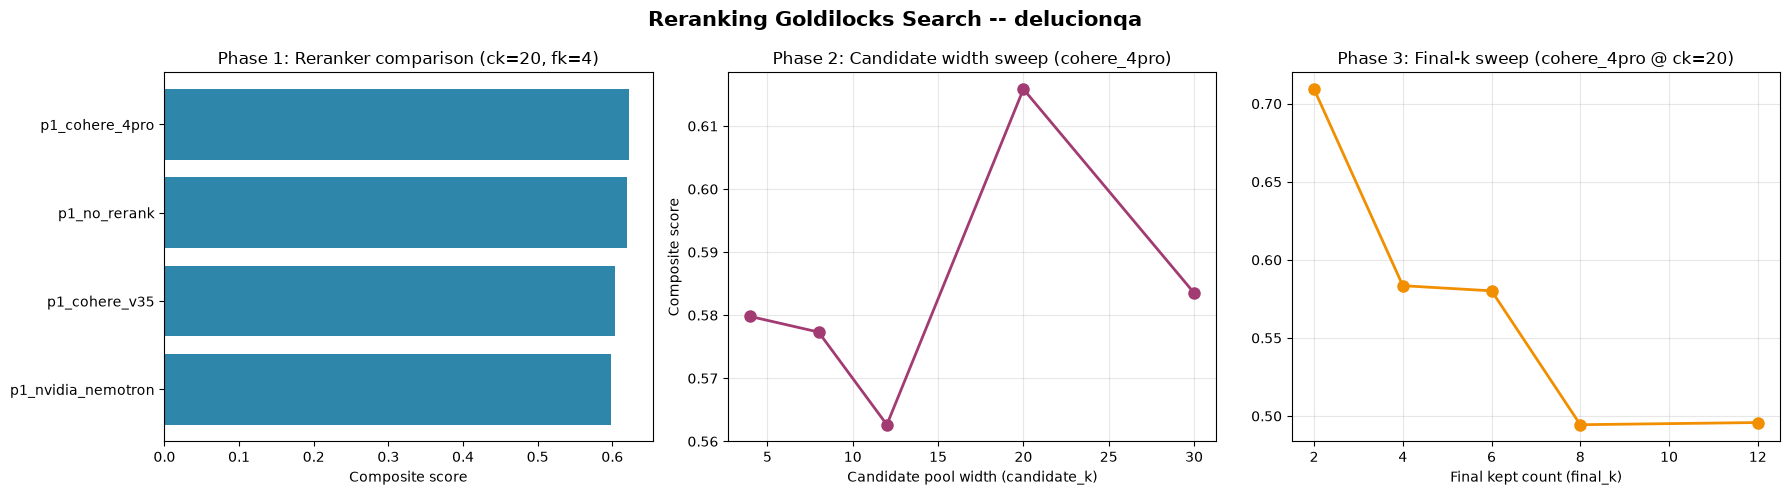

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Reranking Goldilocks Search -- {DATASET_NAME}", fontsize=15, fontweight="bold")

p1_plot = phase1_df.dropna(subset=["composite"]).sort_values("composite")
axes[0].barh(p1_plot["config"], p1_plot["composite"], color="#2E86AB")
axes[0].set_xlabel("Composite score")
axes[0].set_title(f"Phase 1: Reranker comparison (ck={CANDIDATE_K_PHASE1}, fk={FINAL_K_PHASE1})")

p2_plot = phase2_df.dropna(subset=["composite"]).sort_values("candidate_k")
axes[1].plot(p2_plot["candidate_k"], p2_plot["composite"], "o-", color="#A23B72", linewidth=2, markersize=8)
axes[1].set_xlabel("Candidate pool width (candidate_k)")
axes[1].set_ylabel("Composite score")
axes[1].set_title(f"Phase 2: Candidate width sweep ({phase2_method})")
axes[1].grid(True, alpha=0.3)

p3_plot = phase3_df.dropna(subset=["composite"]).sort_values("final_k")
axes[2].plot(p3_plot["final_k"], p3_plot["composite"], "o-", color="#F18F01", linewidth=2, markersize=8)
axes[2].set_xlabel("Final kept count (final_k)")
axes[2].set_title(f"Phase 3: Final-k sweep ({phase2_method} @ ck={phase2_winner_candidate_k})")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 12: Final Recommendation

In [12]:
all_results_df = pd.concat([phase1_df, phase2_df, phase3_df], ignore_index=True)
all_results_df = all_results_df.dropna(subset=["composite"]).sort_values("composite", ascending=False)

print("=" * 100)
print("ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE")
print("=" * 100)
display(all_results_df[[
    "config", "candidate_k", "final_k", "n_eval", "n_failed",
    "context_relevance", "utilization", "completeness", "adherence", "composite",
]])

best = all_results_df.iloc[0]
no_rerank_row = phase1_df[phase1_df["config"] == "p1_no_rerank"].iloc[0]

print("\n" + "=" * 100)
print(f"🏆 GOLDILOCKS RERANKING CONFIG: {best['config']}")
print("=" * 100)
print(f"  Candidate pool width: {best['candidate_k']:.0f}")
print(f"  Final kept count:     {best['final_k']:.0f}")
print(f"  Context Relevance:    {best['context_relevance']:.4f}")
print(f"  Utilization:          {best['utilization']:.4f}")
print(f"  Completeness:         {best['completeness']:.4f}")
print(f"  Adherence:            {best['adherence']:.4f}")
print(f"  Composite:            {best['composite']:.4f}")
print(f"  Eval sample:          {best['n_eval']}/{EVAL_SAMPLE_SIZE} succeeded (failed: {best['n_failed']})")
if no_rerank_row["composite"] is not None and best["config"] != "p1_no_rerank":
    delta = best["composite"] - no_rerank_row["composite"]
    print(f"  vs. no-reranking control: {delta:+.4f} composite ({'worth adopting' if delta > 0 else 'no-reranking control still wins'})")
print("=" * 100)


ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE


,config,candidate_k,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
9,p3_cohere_4pro_ck20_fk2,20,2,20,0,0.619030,0.392085,0.675835,0.95,0.709348
0,p1_cohere_4pro,20,4,20,0,0.488630,0.236220,0.558495,0.95,0.622728
1,p1_no_rerank,20,4,20,0,0.425075,0.223585,0.584640,1.00,0.620010
4,p2_cohere_4pro_ck20,20,4,20,0,0.477180,0.294235,0.597990,0.90,0.615847
2,p1_cohere_v35,20,4,20,0,0.419795,0.239525,0.590000,0.95,0.603857
3,p1_nvidia_nemotron,20,4,20,0,0.456195,0.212665,0.493560,0.95,0.598102
5,p2_cohere_4pro_ck30,30,4,20,0,0.451160,0.212835,0.524655,0.90,0.583530
10,p3_cohere_4pro_ck20_fk4,20,4,20,0,0.491655,0.236320,0.522955,0.85,0.583471
11,p3_cohere_4pro_ck20_fk6,20,6,19,1,0.340563,0.170342,0.569416,1.00,0.580161
6,p2_cohere_4pro_ck4,4,4,20,0,0.371765,0.187875,0.593335,0.95,0.579799



🏆 GOLDILOCKS RERANKING CONFIG: p3_cohere_4pro_ck20_fk2
  Candidate pool width: 20
  Final kept count:     2
  Context Relevance:    0.6190
  Utilization:          0.3921
  Completeness:         0.6758
  Adherence:            0.9500
  Composite:            0.7093
  Eval sample:          20/20 succeeded (failed: 0)
  vs. no-reranking control: +0.0893 composite (worth adopting)


### Caveats -- do not treat these exact numbers as final

- **Still a single run on one fixed 20-question sample.** Retrying failed annotations and
  reusing the same question set across every config removes some noise, but this is one
  dataset draw.
- **Chunking, retriever, and query transformation held constant** at `11`/`12`/`13`'s
  winning configs. Whether a different upstream pipeline changes which reranker (or whether
  reranking helps at all) is not explored here.
- **`query_llm` runs at temperature 0.7** for the HyDE retrieval string, same caveat as
  `13` -- a repeat run could shuffle close results even on the same fixed question set.
- **The OpenRouter rerank endpoint is a third-party dependency** with its own latency, cost,
  and availability characteristics not modeled by the composite score. A reranker that wins
  on quality but adds meaningful per-query latency may still not be worth adopting in
  production -- that tradeoff isn't captured in these numbers.
- **Phase 2/3 both hold candidate pool width and final_k semantics fixed at "top by hybrid
  score, then top by rerank score"** -- other reranking strategies (e.g. reranking multiple
  smaller shards independently, or blending rerank score with the original hybrid score)
  aren't tested.
- **Composite score weighting (0.35/0.15/0.15/0.35) is a judgment call**, kept identical to
  `11`/`12`/`13` for comparability. The raw per-metric columns are in every results table if
  you want to re-rank by a different weighting or a single metric.
